# Doing molecular dynamics with Atomic Simulation Environment(ASE)
-------------------------------------------------------------------------------------------------

## The example before (Melt)

```
units		lj
atom_style	atomic

lattice		fcc 0.8442
region		box block 0 10 0 10 0 10
create_box	1 box
create_atoms	1 box
mass		1 1.0

velocity	all create 3.0 87287 loop geom

pair_style	lj/cut 2.5
pair_coeff	1 1 1.0 1.0 2.5

neighbor	0.3 bin
neigh_modify	every 20 delay 0 check no

fix		1 all nve

#dump		id all atom 50 dump.melt

#dump		2 all image 25 image.*.jpg type type &
#		axes yes 0.8 0.02 view 60 -30
#dump_modify	2 pad 3

#dump		3 all movie 25 movie.mpg type type &
#		axes yes 0.8 0.02 view 60 -30
#dump_modify	3 pad 3

thermo		50
run		250
```

In [1]:
# Import necessary packages

from ase import Atoms
from ase.calculators.lj import LennardJones
from ase.lattice.cubic import FaceCenteredCubic
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.md.verlet import VelocityVerlet
from ase.io import write, Trajectory, read
import matplotlib.pyplot as plt
from ase.visualize import view
import numpy as np


## Convert the lattice constant 
- FCC system:
$$
\text{Density} = \frac{\text{Number of atoms}}{\text{Volume of lattice}} = \frac{4}{a^3}
$$

In [2]:
# Define lattice constant based on density in LAMMPS input
a = (4/0.8442)**(1/3) 
size = 10

# Initialize the FCC lattice
atoms = FaceCenteredCubic(directions=[[1, 0, 0], [0, 1, 0], [0, 0, 1]],
                          symbol="Ar",
                          size=(size, size, size),
                          latticeconstant= a,
                          pbc=True)

# Set atomic masses (consistent with LAMMPS mass 1 1.0)
atoms.set_masses([1.0] * len(atoms)) 


In [3]:
# Set initial velocity distribution at the specified temperature (3 LJ units)
MaxwellBoltzmannDistribution(atoms, temperature_K = 9)

# Set the Lennard-Jones potential with cutoff distance
calc = LennardJones(epsilon=1.0, sigma=1.0, rc=2.5)
atoms.calc = calc

# Define the timestep and the integrator
timestep = 5.0
dyn = VelocityVerlet(atoms, timestep * 1e-3)

# Lists to store time steps, temperature, potential, kinetic, and total energy values
time_step = []
temperature_list = []
epot_list = []
ekin_list = []
etot_list = []

# Function to update neighbors (simulating neighbor list update in LAMMPS)
def update_neighbors():
    atoms.calc = calc

# Function to collect data for plotting and print status    
def print_status(a=atoms):
    epot = a.get_potential_energy()
    ekin = a.get_kinetic_energy()
    etot = a.get_total_energy()
    temp = a.get_temperature()
    
    # Save collected data
    time_step.append(dyn.nsteps)
    temperature_list.append(temp)
    epot_list.append(epot)
    ekin_list.append(ekin)
    etot_list.append(etot)
    
    # Print status
    print(f"Step: {dyn.nsteps}, Temperature: {temp:.2f} K, E_pot: {epot:.4f} eV, E_kin: {ekin:.4f} eV, E_tot: {etot:.4f} eV")
    

### This is the code about how to update the neighbour like the lammps input file
`dyn.attach(update_neighbors,interval = 20)`

In [4]:
# Collect the data    
dyn.attach(print_status, interval= 5)

# Save the trajectory 
traj = Trajectory('melt_trajectory.traj', 'w', atoms)
dyn.attach(traj.write, interval=5)


# 250 steps
dyn.run(250)


Step: 0, Temperature: 8.98 K, E_pot: -25331.2480 eV, E_kin: 4.6437 eV, E_tot: -25326.6043 eV
Step: 5, Temperature: 8.64 K, E_pot: -25331.0705 eV, E_kin: 4.4663 eV, E_tot: -25326.6042 eV
Step: 10, Temperature: 7.67 K, E_pot: -25330.5706 eV, E_kin: 3.9666 eV, E_tot: -25326.6040 eV
Step: 15, Temperature: 6.26 K, E_pot: -25329.8394 eV, E_kin: 3.2357 eV, E_tot: -25326.6037 eV
Step: 20, Temperature: 4.65 K, E_pot: -25329.0081 eV, E_kin: 2.4048 eV, E_tot: -25326.6033 eV
Step: 25, Temperature: 3.13 K, E_pot: -25328.2220 eV, E_kin: 1.6190 eV, E_tot: -25326.6030 eV
Step: 30, Temperature: 1.95 K, E_pot: -25327.6113 eV, E_kin: 1.0085 eV, E_tot: -25326.6027 eV
Step: 35, Temperature: 1.28 K, E_pot: -25327.2664 eV, E_kin: 0.6637 eV, E_tot: -25326.6026 eV
Step: 40, Temperature: 1.20 K, E_pot: -25327.2218 eV, E_kin: 0.6191 eV, E_tot: -25326.6027 eV
Step: 45, Temperature: 1.64 K, E_pot: -25327.4528 eV, E_kin: 0.8499 eV, E_tot: -25326.6029 eV
Step: 50, Temperature: 2.48 K, E_pot: -25327.8855 eV, E_kin: 1

True

# Using Python for Data Analysis

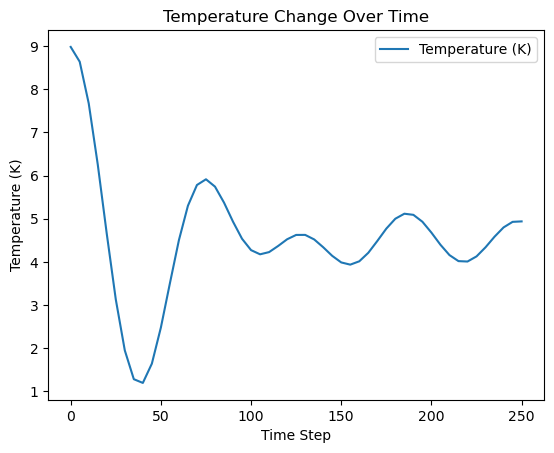

In [7]:
# Plot Temperature change over time
plt.figure()
plt.plot(time_step, temperature_list, label='Temperature (K)')
plt.xlabel('Time Step')
plt.ylabel('Temperature (K)')
plt.legend()
plt.title('Temperature Change Over Time')
plt.show()

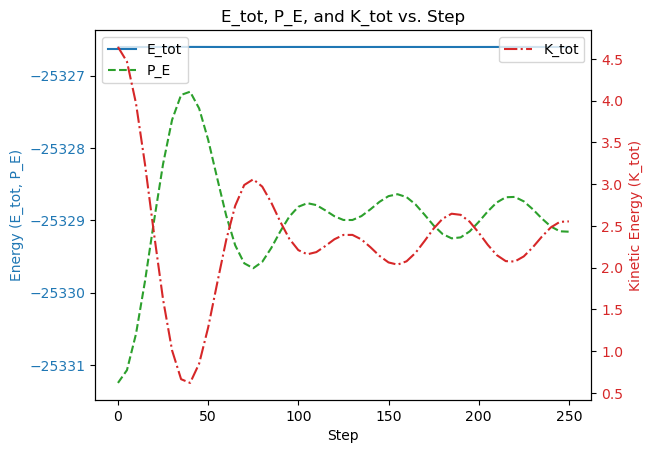

In [8]:
fig, ax1 = plt.subplots()

ax1.set_xlabel('Step')
ax1.set_ylabel('Energy (E_tot, P_E)', color='tab:blue')
ax1.plot(time_step, etot_list, label='E_tot', color='tab:blue', linestyle='-')
ax1.plot(time_step, epot_list, label='P_E', color='tab:green', linestyle='--')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper left')

# Create a second y-axis (y2) sharing the same x-axis
ax2 = ax1.twinx()
ax2.set_ylabel('Kinetic Energy (K_tot)', color='tab:red')
ax2.plot(time_step, ekin_list, label='K_tot', color='tab:red', linestyle='-.')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.legend(loc='upper right')

# Add a title and display the plot
plt.title('E_tot, P_E, and K_tot vs. Step')
plt.show()

# Animation

In [14]:
output = read("melt_trajectory.traj@:")
view(output,viewer='ngl')


TypeError: 'NGLWidget' object is not callable

In [12]:
import nglview as nv
atoms = read("melt_trajectory.traj", ":")  # ':' means all frames
view = nv.show_asetraj(atoms)
view

NGLWidget(max_frame=50)

In [15]:
from ase.io.trajectory import Trajectory
import nglview as nv

traj = Trajectory('melt_trajectory.traj')  # open trajectory (all frames)
view = nv.show_asetraj(traj)
view.add_ball_and_stick()
view


NGLWidget(max_frame=50)

In [17]:
t = Trajectory('melt_trajectory.traj')
print(f"Number of frames: {len(t)}")
print(type(t))
print(len(t))
print(type(t[0]))

Number of frames: 51
<class 'ase.io.trajectory.TrajectoryReader'>
51
<class 'ase.atoms.Atoms'>


In [18]:
from ase.build import molecule
from ase.io.trajectory import Trajectory
import nglview as nv

# Create a simple test trajectory (5 frames)
atoms = molecule("H2O")
with Trajectory("test.traj", "w", atoms) as traj:
    for i in range(5):
        atoms.translate([0.1, 0, 0])
        traj.write(atoms)

# Reload and show
from ase.io.trajectory import Trajectory
t = Trajectory("test.traj")
print(len(t))  # Should print 5

view = nv.show_asetraj(t)
view.add_ball_and_stick()
view


5


NGLWidget(max_frame=4)